In [1]:
import os
import sys

sys.path.append("..")
import torch

## Self-Organizing

In [2]:
with open("../Log/exp_21/output_log.txt") as f:
    lines = f.readlines()

layer0_result_dicts = {
    "Epoch": [],
    "num_neurons_layer_0": [],
    "dup_neurons_layer_0": [],
    "del_neurons_layer_0": [],
}
for line in lines:
    if line.split(":")[0] == "Epoch":
        layer0_result_dicts["Epoch"].append(int(line.split(":")[1]))
    elif line.split(":")[0] == "num_neurons_layer_0":
        layer0_result_dicts["num_neurons_layer_0"].append(
            int(line.split(":")[1].split("(")[1][:-2])
        )
    elif line.split(":")[0] == "dup_neurons_layer_0":
        layer0_result_dicts["dup_neurons_layer_0"].append(
            int(float(line.split(":")[1][:-1]))
        )
    elif line.split(":")[0] == "del_neurons_layer_0":
        layer0_result_dicts["del_neurons_layer_0"].append(
            int(float(line.split(":")[1][:-1]))
        )
    else:
        continue

/tmp/ipykernel_10330/3356808717.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab20c')
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


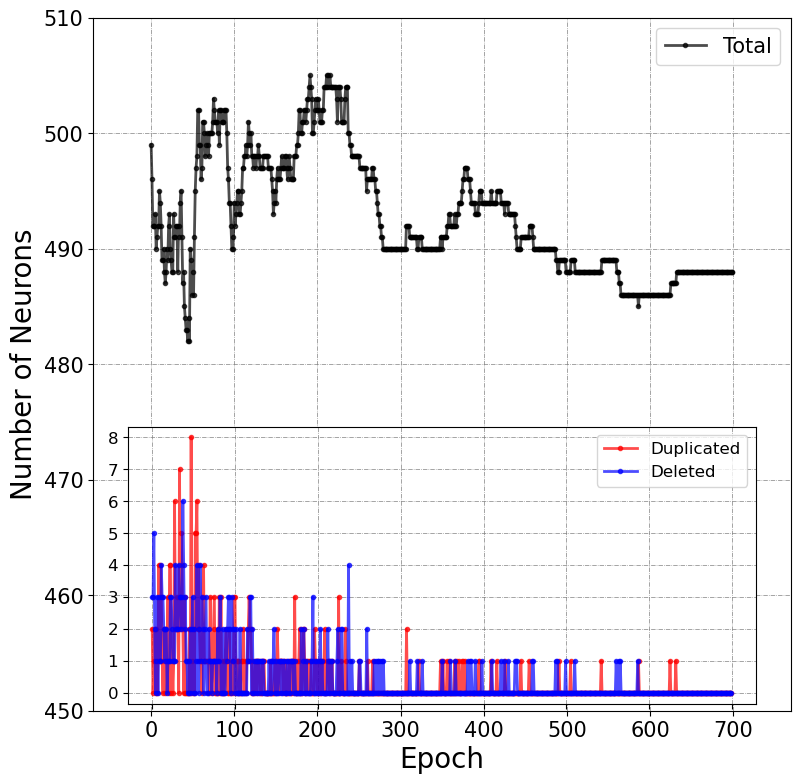

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1, 1, figsize=(9,9))

cmap = plt.cm.get_cmap('tab20c')
colors = cmap(np.linspace(0, 1, 3))

ax.margins(x=0.1, y=0.1)
ax.set_xlabel('Epoch', fontsize='20')
ax.set_ylabel('Number of Neurons', fontsize='20')
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.set_ylim(450, 510)
ax.plot(layer0_result_dicts["Epoch"], layer0_result_dicts["num_neurons_layer_0"], marker='.', color="k", alpha=0.7, linewidth=2, linestyle='-')

ax.grid(ls="-.", lw=0.5, c="grey")
ax.legend()

axins1 = inset_axes(ax, width="90%", height="40%", loc='upper left', bbox_to_anchor=(0.04, -0.58, 1, 1), bbox_transform=ax.transAxes)
axins1.plot(layer0_result_dicts["Epoch"], layer0_result_dicts["dup_neurons_layer_0"], marker='.', color="r", alpha=0.7, linewidth=2, linestyle='-')
axins1.plot(layer0_result_dicts["Epoch"], layer0_result_dicts["del_neurons_layer_0"], marker='.', color="b", alpha=0.7, linewidth=2, linestyle='-')

# axins1.set_ylim(-0.5, 12)
# axins1.tick_params(axis='x', labelsize=15)
axins1.set_xticklabels([])
axins1.tick_params(axis='y', labelsize=12)
axins1.yaxis.set_major_locator(MaxNLocator(integer=True))
axins1.grid(ls="-.", lw=0.5, c="grey")
axins1.margins(x=0.042, y=0.042)

ax.legend(["Total"], prop={'size':15})
axins1.legend([ "Duplicated", "Deleted"], prop={'size':12})
plt.savefig('MNIST_Neuron_Adj.svg', bbox_inches='tight', pad_inches=0, dpi=1200)
plt.show()

In [4]:
from model import FF_TE, utils
from config import config

train_set = FF_TE.FF_MNIST("train")
val_set = FF_TE.FF_MNIST("val")
test_set = FF_TE.FF_MNIST("test")
trn_loader = torch.utils.data.DataLoader(
    train_set,
    config.batch_size,
    drop_last=True,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)
val_loader = torch.utils.data.DataLoader(
    val_set,
    config.batch_size,
    drop_last=True,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)
tst_loader = torch.utils.data.DataLoader(
    test_set,
    config.batch_size,
    drop_last=True,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

In [25]:
import torch
from model import FF_RBF

model = torch.load("../Log/exp_21/output_model.pth").to(torch.device(config.device))
with torch.no_grad():
    pos_embeddings = []
    neg_embeddings = []
    true_labels = []
    for inputs, labels in tst_loader:
        inputs, labels = utils.preprocess_inputs(inputs, labels)

        pos_z, neg_z = model.embedding(inputs)
        pos_embeddings.append(pos_z)
        neg_embeddings.append(neg_z)
        true_labels.append(labels["class_labels"])
    pos_embeddings = torch.cat(pos_embeddings, dim=0)
    neg_embeddings = torch.cat(neg_embeddings, dim=0)
    true_labels = torch.cat(true_labels, dim=0)

In [26]:
embeddings = torch.concat([pos_embeddings, neg_embeddings], dim=0).cpu().numpy()
labels = np.ones(embeddings.shape[0])
labels[: neg_embeddings.shape[0]] = 0


from sklearn.manifold import TSNE

X_embedded = TSNE(
    n_components=2,
    learning_rate=1500,
    perplexity=100,
    max_iter=1000,
    early_exaggeration=5,
).fit_transform(embeddings)
X_norm = (X_embedded - X_embedded.min(0)) / (X_embedded.max(0) - X_embedded.min(0))

/tmp/ipykernel_10330/3929915711.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("Dark2")
/tmp/ipykernel_10330/3929915711.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(
/tmp/ipykernel_10330/3929915711.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


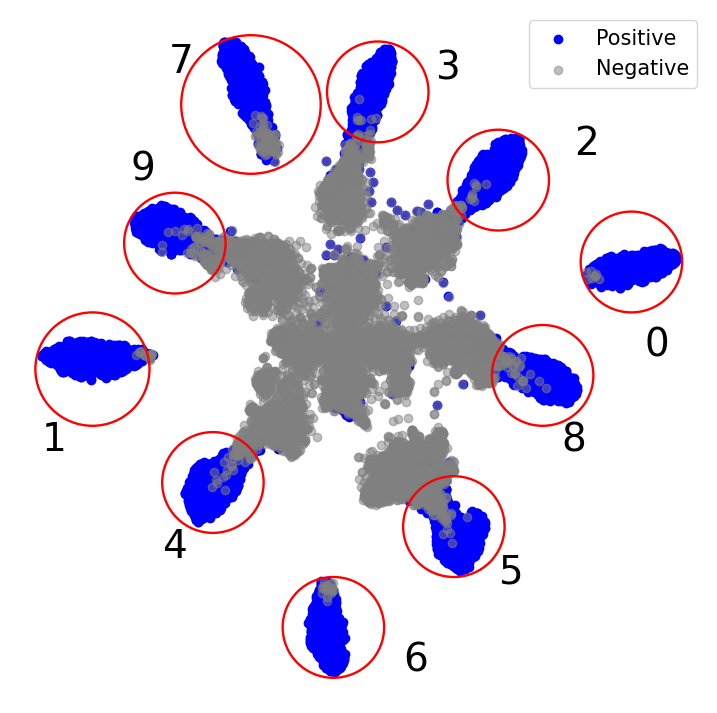

<Figure size 640x480 with 0 Axes>

In [77]:
cmap = plt.cm.get_cmap("Dark2")
colors = cmap(np.linspace(0, 1, 2))

plt.figure(figsize=(9, 9))
plt.scatter(
    X_norm[: pos_embeddings.shape[0], 0],
    X_norm[: pos_embeddings.shape[0], 1],
    c="b",
    label="Positive",
    cmap="Dark2",
)
plt.scatter(
    X_norm[pos_embeddings.shape[0] :, 0],
    X_norm[pos_embeddings.shape[0] :, 1],
    c="grey",
    alpha=0.5,
    label="Negative",
    cmap="Dark2",
)

for spine in plt.gcf().gca().spines.values():
    spine.set_visible(False)

plt.gcf().gca().add_artist(
    plt.Circle((0.46, 0.07), 0.08, lw=1.7, edgecolor="r", fill=False)
)
plt.text(0.57, 0, "6", fontsize=28)

plt.gcf().gca().add_artist(
    plt.Circle((0.93, 0.65), 0.08, lw=1.7, edgecolor="r", fill=False)
)
plt.text(0.95, 0.50, "0", fontsize=28)

plt.gcf().gca().add_artist(
    plt.Circle((0.65, 0.23), 0.08, lw=1.7, edgecolor="r", fill=False)
)
plt.text(0.72, 0.14, "5", fontsize=28)

plt.gcf().gca().add_artist(
    plt.Circle((0.79, 0.47), 0.08, lw=1.7, edgecolor="r", fill=False)
)
plt.text(0.82, 0.35, "8", fontsize=28)

plt.gcf().gca().add_artist(
    plt.Circle((0.21, 0.68), 0.08, lw=1.7, edgecolor="r", fill=False)
)
plt.text(0.14, 0.78, "9", fontsize=28)

plt.gcf().gca().add_artist(
    plt.Circle((0.08, 0.48), 0.09, lw=1.7, edgecolor="r", fill=False)
)
plt.text(0, 0.35, "1", fontsize=28)

plt.gcf().gca().add_artist(
    plt.Circle((0.27, 0.30), 0.08, lw=1.7, edgecolor="r", fill=False)
)
plt.text(0.19, 0.18, "4", fontsize=28)

plt.gcf().gca().add_artist(
    plt.Circle((0.53, 0.92), 0.08, lw=1.7, edgecolor="r", fill=False)
)
plt.text(0.62, 0.94, "3", fontsize=28)

plt.gcf().gca().add_artist(
    plt.Circle((0.72, 0.78), 0.08, lw=1.7, edgecolor="r", fill=False)
)
plt.text(0.84, 0.82, "2", fontsize=28)

plt.gcf().gca().add_artist(
    plt.Circle((0.33, 0.90), 0.11, lw=1.7, edgecolor="r", fill=False)
)
plt.text(0.20, 0.95, "7", fontsize=28)
# plt.title(
#     "RBF Embeddings",
#     fontdict={"family": "Times New Roman", "fontsize": 35},
# )
plt.xticks([])
plt.yticks([])
plt.legend(prop={"size": 15})
plt.savefig("MNIST_ARBF_Embedding.svg", bbox_inches="tight", pad_inches=0, dpi=1200)
plt.show()
plt.clf()